# `Industrial Machine Learning on Hadoop and Spark`
## `Seminar 08: Spark ML`

### `Maks Nakhodnov`
#### `Bremen, 2025`

From this notebook, you can learn about:
    
* RDD API ML: Simple Spark Algorithms
* Histograms in Spark
* Implementation of ML Pipeline in Spark:
    1. Visualization
    2. Preprocessing
    3. Model Training
    4. Quality Evaluation

## `Initialization`

In [1]:
! rm -rf tweets/
! rm -rf m5-forecasting-accuracy/
! rm -rf default-of-credit-card-clients-dataset/

In [2]:
import os
import sys
import multiprocessing
from functools import partial
from typing import Iterator, Tuple

os.environ['PYSPARK_DRIVER_PYTHON'] = os.environ['PYSPARK_PYTHON'] = sys.executable

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import pyspark
import pyspark.sql
import pyspark.sql.dataframe
from pyspark.sql import SparkSession
from pyspark import SparkConf, SparkContext

import pyspark.sql.types as T
import pyspark.sql.functions as F
from pyspark.sql.window import Window
from pyspark.accumulators import AccumulatorParam

import pyarrow.compute as pc

In [4]:
conf = (
    SparkConf()
        .set('spark.driver.memory','12g')
        .set('spark.ui.port', '4051')
        .set('spark.sql.ansi.enabled', 'false')
        .setMaster('local[*]')
)
sc = SparkContext(conf=conf)
spark = SparkSession(sc)

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
25/11/10 22:30:08 WARN Utils: Your hostname, DESKTOP-8FB26C5, resolves to a loopback address: 127.0.1.1; using 172.18.120.163 instead (on interface eth0)
25/11/10 22:30:08 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/11/10 22:30:09 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


## `Spark Winsorizing`

Winsorization is a method of preprocessing numerical data, where values outside specified quantiles are replaced with the values of those quantiles.

For example, let $X = \{100, 6, 52, 26, 8, 81, 52, 15, 2, 74, 93, 82, 36, 22, 74, 90, 97, 50, 4, 40, 1\}$.

Winsorization for the 0.1 and 0.9 quantiles is performed as follows:

1. Determine the quantiles: $q_{0.1} = 3, q_{0.9} = 93$
2. Replace all values less than $3$ with $3$ and all values greater than $93$ with $93$:

$$\hat{X} = \{93, 6, 52, 26, 8, 81, 52, 15, 3, 74, 93, 82, 36, 22, 74, 90, 97, 50, 4, 40, 3\}$$

This preprocessing removes extreme values and outliers, leading to more reliable computation of statistics for the sample (mean, variance, etc.).


In [5]:
def winsorizing(
    df: pyspark.sql.dataframe.DataFrame,
    column: str = 'sales',
    lower_percentile: float = 0.1,
    higher_percentile: float = 0.9,
    partition_column: str = 'fruit',
) -> pyspark.sql.dataframe.DataFrame:
    wspec = Window().partitionBy(partition_column)

    lp_column = '_'.join([column, 'lower_percentile'])
    hp_column = '_'.join([column, 'higher_percentile'])
    df = df.withColumns({
        lp_column: F.percentile_approx(F.col(column), lower_percentile).over(wspec),
        hp_column: F.percentile_approx(F.col(column), higher_percentile).over(wspec)
    })

    df = (
        df
            .withColumn(
                '_'.join([column, 'winsorized']),
                F.when(
                    F.col(column) < F.col(lp_column),
                    F.col(lp_column)
                ).otherwise(
                    F.when(
                        F.col(column) > F.col(hp_column),
                        F.col(hp_column)
                    ).otherwise(
                        F.col(column)
                    )
                )
            )
    )

    return df

In [6]:
schema = T.StructType([
       T.StructField('fruit', T.StringType(), False),
       T.StructField('sales', T.DoubleType(), False),
])
data = list(zip(
    np.random.choice(['Apple', 'Plum', 'Melone'], 1000).tolist(),
    np.random.randn(1000).tolist()
))

df = spark.createDataFrame(data, schema=schema)
df.limit(10).show()

+------+--------------------+
| fruit|               sales|
+------+--------------------+
|Melone| 0.21328750275775343|
| Apple|   2.439981505787967|
|Melone|-0.00171595056931...|
|  Plum| 0.11164789300845288|
| Apple| 0.10414762783524117|
|Melone|  0.7411634565572897|
|Melone| 0.18904568040214834|
|  Plum| -1.1247426845310269|
|  Plum|  2.3822659560268336|
| Apple|  1.1488067327486438|
+------+--------------------+



In [7]:
df_w = winsorizing(df).cache()
df_w.limit(10).toPandas()

,fruit,sales,sales_lower_percentile,sales_higher_percentile,sales_winsorized
0,Plum,0.111648,-1.294231,1.098864,0.111648
1,Plum,-1.124743,-1.294231,1.098864,-1.124743
2,Plum,2.382266,-1.294231,1.098864,1.098864
3,Plum,-0.830672,-1.294231,1.098864,-0.830672
4,Plum,-0.045723,-1.294231,1.098864,-0.045723
5,Plum,-0.723862,-1.294231,1.098864,-0.723862
6,Plum,1.838503,-1.294231,1.098864,1.098864
7,Plum,-0.585205,-1.294231,1.098864,-0.585205
8,Plum,0.181389,-1.294231,1.098864,0.181389
9,Plum,-0.196825,-1.294231,1.098864,-0.196825


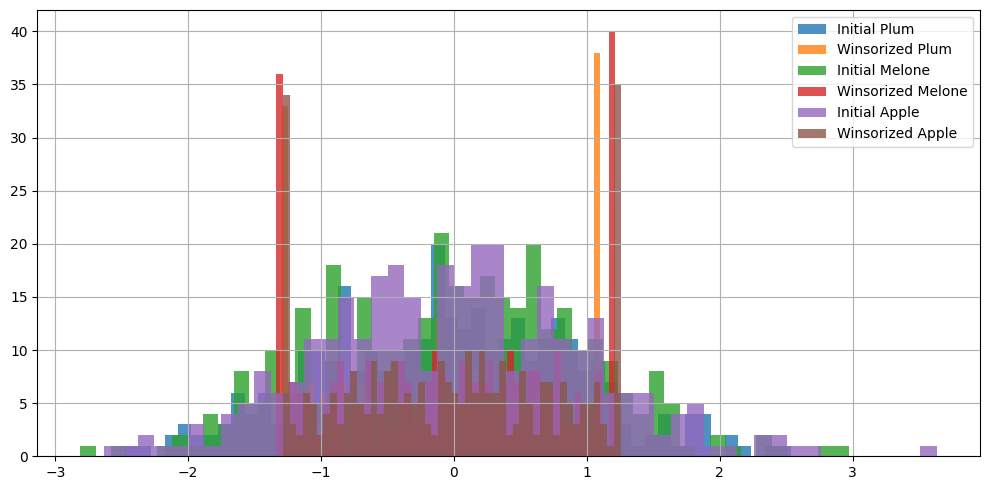

In [8]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5))

for fruit in df.select(df.fruit).distinct().collect():
    fruit = fruit.fruit
    ax.hist(
        df.filter(df.fruit == F.lit(fruit)).rdd.map(lambda row: row.sales).collect(),
        bins=50, label=f'Initial {fruit}', alpha=0.8
    )
    ax.hist(
        df_w.filter(df_w.fruit == F.lit(fruit)).rdd.map(lambda row: row.sales_winsorized).collect(),
        bins=50, label=f'Winsorized {fruit}', alpha=0.8
    )

ax.legend()
ax.grid(True)
fig.tight_layout()
plt.show()

## `Spark RDD Gradient Descent`

$$
D = \{(x_{i}, y_{i}) | x_{i} \in \mathbb{R}^{d}, y \in \mathbb{R}\}_{1}^{n}
$$
$$
\hat{y}_{i} = \langle x, w \rangle + b
$$
$$
L_{i} = \frac{1}{2} (\hat{y}_{i} - y_{i})^{2}
$$
$$
\mathfrak{L}(w, b) = \frac{1}{n}\sum\limits_{i=1}^{n} L_{i} \longrightarrow \min_{w, b}
$$

It’s necessary to find the optimal $w \in \mathbb{R}^{d}, b \in \mathbb{R}$

One approach to solving the problem: Gradient Descent (GD):

$$
w^{i+1} = w^{i} - \alpha \nabla_{w}\mathfrak{L}
$$
$$
b^{i+1} = b^{i} - \alpha \nabla_{b}\mathfrak{L}
$$

### `Synthetic data`

**Data model:**
$$
y_{i} \sim \mathcal{N}(\langle x_{i}, w^{*} \rangle, \sigma^{2})
$$

In [9]:
X = np.random.randn(50000, 100)
w_star = np.random.randn(X.shape[1])
y = X.dot(w_star) + 0.01 * np.random.randn(X.shape[0])

$$\nabla_{w} L = (\frac{\partial L}{\partial w_{1}}, ..., \frac{\partial L}{\partial w_{d}})$$

$$
\nabla_{w} \mathfrak{L} = \frac{1}{n} \sum\limits_{i=1}^{n} \nabla_{w}(\hat{y}_{i} - y_{i})(\hat{y}_{i} - y_{i}) = \frac{1}{n} \sum\limits_{i=1}^{n} (\hat{y}_{i} - y_{i}) \nabla_{w}\hat{y}_{i} = \frac{1}{n} \sum\limits_{i=1}^{n} (\hat{y}_{i} - y_{i}) x_{i} = \frac{1}{n} \sum\limits_{i=1}^{n} (\langle x_{i}, w \rangle - y_{i}) x_{i}
$$

In [10]:
def gradient_descent_mse(X, y, alpha=0.1, epochs=1, n_partitions=100, log_freq=3):
    history = []

    X_rdd = sc.parallelize(X, numSlices=n_partitions).cache()
    y_rdd = sc.parallelize(y, numSlices=n_partitions).cache()

    print(f'Number of partitions: {X_rdd.getNumPartitions()}')

    n, d = X_rdd.count(), X_rdd.take(1)[0].shape[0]

    # Cache the computation result to avoid recalculating it on each iteration
    X_y_rdd = X_rdd.zip(y_rdd).cache()

    # 1. Init w
    w = np.zeros(d)
    # 2. In loop repeat:
    for epoch in range(epochs):
        w_br = sc.broadcast(w)
        n_br = sc.broadcast(n)

        total_error = sc.accumulator(0.0)
        def grad_mapper(x_y, total_error):
            x, y = x_y

            delta = (np.sum(x * w_br.value) - y)
            error = (delta ** 2.0) / 2.0
            total_error.add(error / n_br.value)
            return x * delta

        # a. Calculate error, gradient
        grad = X_y_rdd.map(
            partial(grad_mapper, total_error=total_error)
        ).sum() / n
        # grad = X_y_rdd.map(
        #     partial(grad_mapper, total_error=total_error)
        # ).treeReduce(lambda x, y: x + y, depth=10) / n
        # b. Update w
        w = w - alpha * grad

        history.append(total_error.value)
        if epoch % log_freq == 0:
            print(
                'Epoch: {0:d}, Loss {1:.3f}'.format(
                    epoch, total_error.value
                )
            )
        w_br.unpersist(blocking=True)
        n_br.unpersist(blocking=True)

    X_rdd.unpersist(blocking=True)
    y_rdd.unpersist(blocking=True)
    X_y_rdd.unpersist(blocking=True)

    # 3. Return w
    return w, history

In [11]:
w, history = gradient_descent_mse(X, y, alpha=0.1, epochs=20)

Number of partitions: 100
Epoch: 0, Loss 45.728
Epoch: 3, Loss 24.117
Epoch: 6, Loss 12.732
Epoch: 9, Loss 6.727
Epoch: 12, Loss 3.558
Epoch: 15, Loss 1.884
Epoch: 18, Loss 0.998


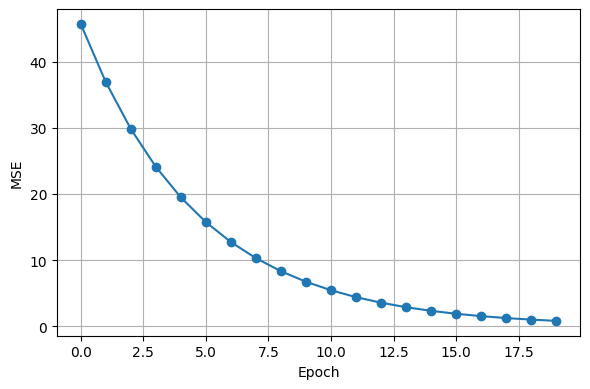

In [12]:
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
ax.plot(history, marker='o')

ax.grid(True)
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE')

fig.tight_layout()
plt.show()

### `Something trickier`

In [13]:
import sklearn.datasets
import sklearn.model_selection

In [14]:
data = sklearn.datasets.fetch_california_housing(download_if_missing=True, return_X_y=False)
X, y = data.data, data.target

X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(X, y, train_size=0.7, shuffle=True)
data.feature_names, X_train.shape, y_train.shape, X_test.shape, y_test.shape

(['MedInc',
  'HouseAge',
  'AveRooms',
  'AveBedrms',
  'Population',
  'AveOccup',
  'Latitude',
  'Longitude'],
 (14447, 8),
 (14447,),
 (6193, 8),
 (6193,))

In [15]:
w, history = gradient_descent_mse(X_train, y_train, alpha=5e-8, epochs=40, log_freq=10)

Number of partitions: 100
Epoch: 0, Loss 2.805
Epoch: 10, Loss 1.529
Epoch: 20, Loss 1.489
Epoch: 30, Loss 1.483


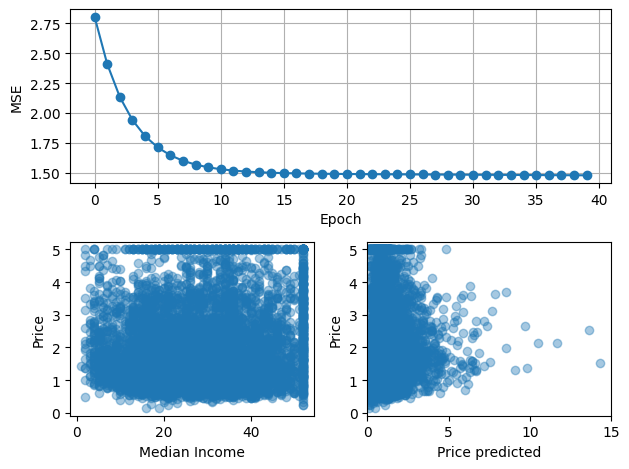

In [16]:
fig = plt.figure(layout=None)
gs = fig.add_gridspec(nrows=2, ncols=2)

ax_top = fig.add_subplot(gs[:-1, :])
ax_left = fig.add_subplot(gs[-1, :-1])
ax_right = fig.add_subplot(gs[-1, -1])

ax_top.plot(history, marker='o')

ax_top.grid(True)
ax_top.set_xlabel('Epoch')
ax_top.set_ylabel('MSE')

ax_left.scatter(X_test[:, 1], y_test, alpha=0.4)
ax_right.scatter(X_test.dot(w), y_test, alpha=0.4)

ax_left.set_xlabel('Median Income')
ax_left.set_ylabel('Price')

ax_right.set_xlabel('Price predicted')
ax_right.set_ylabel('Price')
ax_right.set_xlim(0, 15)

fig.tight_layout()
plt.show()

The result is sad, we need more complex models... I’d like something similar to sklearn, but distributed.

## `Spark MLlib (RDD API)`

In [17]:
from pyspark.mllib.feature import LabeledPoint
from pyspark.mllib.tree import GradientBoostedTrees
from pyspark.mllib.regression import LinearRegressionWithSGD

In [18]:
X_train_rdd, X_test_rdd = sc.parallelize(X_train), sc.parallelize(X_test)
y_train_rdd, y_test_rdd = sc.parallelize(y_train), sc.parallelize(y_test)

X_y_test_rdd = X_test_rdd.zip(y_test_rdd).map(lambda pair: LabeledPoint(pair[1], pair[0])).cache()
X_y_train_rdd = X_train_rdd.zip(y_train_rdd).map(lambda pair: LabeledPoint(pair[1], pair[0])).cache()

In [19]:
linear_model = LinearRegressionWithSGD()
fitted_linear_model = linear_model.train(data=X_y_train_rdd, step=3e-6)

/home/maksim64/miniconda3/lib/python3.13/site-packages/pyspark/mllib/regression.py:365: FutureWarning: Deprecated in 2.0.0. Use ml.regression.LinearRegression.
  warnings.warn("Deprecated in 2.0.0. Use ml.regression.LinearRegression.", FutureWarning)
25/11/10 22:30:43 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS


Let's calculate the loss:

In [20]:
y_pred_rdd = fitted_linear_model.predict(X_y_test_rdd.map(lambda point: point.features)).cache()
mse = y_pred_rdd.zip(y_test_rdd).map(lambda pair: (pair[0] - pair[1]) ** 2).aggregate(0, lambda x, y: x + y, lambda x, y: x + y) / X_test_rdd.count()

print(f'MSE: {mse:.2f}')

MSE: 2.47


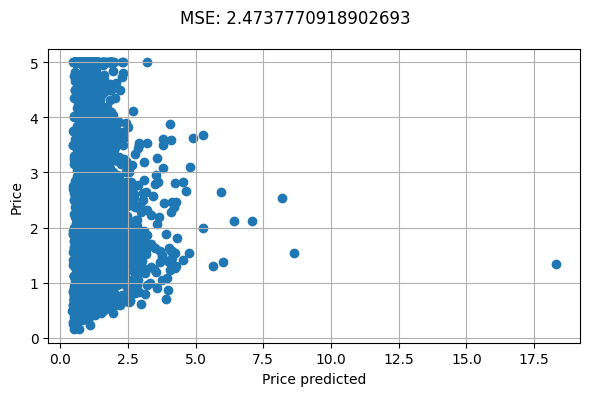

In [21]:
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
ax.scatter(y_pred_rdd.collect(), y_test_rdd.collect())
ax.set_xlabel('Price predicted')
ax.set_ylabel('Price')
ax.grid()

fig.suptitle(f'MSE: {mse}')
fig.tight_layout()
plt.show()

And now something more complex:

In [22]:
gb_model = GradientBoostedTrees()
fitted_gb_model = gb_model.trainRegressor(data=X_y_train_rdd, categoricalFeaturesInfo={})

In [23]:
y_pred_rdd = fitted_gb_model.predict(X_y_test_rdd.map(lambda point: point.features)).cache()
mse = y_pred_rdd.zip(y_test_rdd).map(lambda pair: (pair[0] - pair[1]) ** 2).aggregate(0, lambda x, y: x + y, lambda x, y: x + y) / X_test_rdd.count()

print(f'MSE: {mse:.2f}')

MSE: 0.29


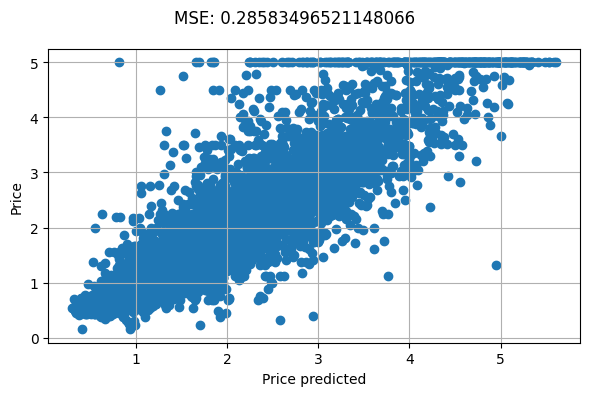

In [24]:
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
ax.scatter(y_pred_rdd.collect(), y_test_rdd.collect())
ax.set_xlabel('Price predicted')
ax.set_ylabel('Price')
ax.grid()

fig.suptitle(f'MSE: {mse}')
fig.tight_layout()
plt.show()

Much better already!

## `Data Analysis Plan`

1. Load data for training
2. Visualize the data and find insights
3. Process the data before model training
4. Train the model on the training dataset
5. Validate the model on the test dataset

### `Load data`

In [25]:
path = "./default-of-credit-card-clients-dataset"
! kaggle datasets download -d uciml/default-of-credit-card-clients-dataset
! unzip default-of-credit-card-clients-dataset.zip  -d $path
! rm -rf default-of-credit-card-clients-dataset.zip

Dataset URL: https://www.kaggle.com/datasets/uciml/default-of-credit-card-clients-dataset
License(s): CC0-1.0
  0%|                                               | 0.00/0.98M [00:00<?, ?B/s]
100%|███████████████████████████████████████| 0.98M/0.98M [00:00<00:00, 170MB/s]
Archive:  default-of-credit-card-clients-dataset.zip
  inflating: ./default-of-credit-card-clients-dataset/UCI_Credit_Card.csv  


In [26]:
# Set the paths to files from the dataset
data_file = f"{path}/UCI_Credit_Card.csv"

file_type = "csv"
infer_schema = "true"
first_row_is_header = "true"
delimiter = ","

data = (
    spark.read.format(file_type)
      .option("inferSchema", infer_schema)
      .option("header", first_row_is_header)
      .option("sep", delimiter)
      .load(data_file)
)

### `EDA. Visualization` 

In [27]:
data = data.withColumnRenamed('default.payment.next.month', 'IS_DEFAULT')
data.limit(10).toPandas()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,IS_DEFAULT
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0
5,6,50000.0,1,1,2,37,0,0,0,0,...,19394.0,19619.0,20024.0,2500.0,1815.0,657.0,1000.0,1000.0,800.0,0
6,7,500000.0,1,1,2,29,0,0,0,0,...,542653.0,483003.0,473944.0,55000.0,40000.0,38000.0,20239.0,13750.0,13770.0,0
7,8,100000.0,2,2,2,23,0,-1,-1,0,...,221.0,-159.0,567.0,380.0,601.0,0.0,581.0,1687.0,1542.0,0
8,9,140000.0,2,3,1,28,0,0,2,0,...,12211.0,11793.0,3719.0,3329.0,0.0,432.0,1000.0,1000.0,1000.0,0
9,10,20000.0,1,3,2,35,-2,-2,-2,-2,...,0.0,13007.0,13912.0,0.0,0.0,0.0,13007.0,1122.0,0.0,0


#### `Available Features`

The data contains three types of variables:

* ID — index
* Target: **IS_DEFAULT**, presence of default in September
* Other variables: $23$ variables that can be used to predict the target variable.

|        Column Name        |                                               Meaning                                               |
| :-----------------------: | :-------------------------------------------------------------------------------------------------: |
|         LIMIT_BAL         |                                         Credit limit amount                                         |
|            SEX            |                                    Gender (1 - male, 2 - female)                                    |
|         EDUCATION         |                      Education level (1 - master’s, 2 - bachelor’s, 3 - school)                     |
|          MARRIAGE         |                               Marital status (1 - married, 2 - single)                              |
|            AGE            |                                                 Age                                                 |
|  PAY_6, ..., PAY2, PAY_0  | Credit repayment status from April to September (-1 - no debt, other # - payment delay by # months) |
| BILL_AMT6, ..., BILL_AMT1 |                    Amount on the card for the billing period from April to August                   |
|  PAY_AMT6, ..., PAY_AMT1  |                         Amount of the previous payment from April to August                         |
|       **IS_DEFAULT**      |                        **Target variable:** credit card default in September                        |


In [28]:
data.printSchema()

root
 |-- ID: integer (nullable = true)
 |-- LIMIT_BAL: double (nullable = true)
 |-- SEX: integer (nullable = true)
 |-- EDUCATION: integer (nullable = true)
 |-- MARRIAGE: integer (nullable = true)
 |-- AGE: integer (nullable = true)
 |-- PAY_0: integer (nullable = true)
 |-- PAY_2: integer (nullable = true)
 |-- PAY_3: integer (nullable = true)
 |-- PAY_4: integer (nullable = true)
 |-- PAY_5: integer (nullable = true)
 |-- PAY_6: integer (nullable = true)
 |-- BILL_AMT1: double (nullable = true)
 |-- BILL_AMT2: double (nullable = true)
 |-- BILL_AMT3: double (nullable = true)
 |-- BILL_AMT4: double (nullable = true)
 |-- BILL_AMT5: double (nullable = true)
 |-- BILL_AMT6: double (nullable = true)
 |-- PAY_AMT1: double (nullable = true)
 |-- PAY_AMT2: double (nullable = true)
 |-- PAY_AMT3: double (nullable = true)
 |-- PAY_AMT4: double (nullable = true)
 |-- PAY_AMT5: double (nullable = true)
 |-- PAY_AMT6: double (nullable = true)
 |-- IS_DEFAULT: integer (nullable = true)



In [29]:
data.summary().toPandas()

25/11/10 22:30:59 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


,summary,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,IS_DEFAULT
0,count,30000,30000,30000,30000,30000,30000,30000,30000,30000,...,30000,30000,30000,30000,30000,30000,30000,30000,30000,30000
1,mean,15000.5,167484.32266666667,1.6037333333333332,1.8531333333333333,1.5518666666666667,35.4855,-0.0167,-0.13376666666666667,-0.1662,...,43262.94896666666,40311.40096666667,38871.7604,5663.5805,5921.1635,5225.6815,4826.076866666666,4799.387633333334,5215.502566666667,0.2212
2,stddev,8660.398374208891,129747.66156720246,0.4891291960902602,0.7903486597207269,0.5219696006132467,9.217904068090155,1.1238015279973335,1.1971859730345495,1.1968675684465686,...,64332.856133916444,60797.15577026471,59554.1075367459,16563.28035402577,23040.870402057186,17606.96146980311,15666.159744032062,15278.305679144742,17777.46577543531,0.41506180569093254
3,min,1,10000.0,1,0,0,21,-2,-2,-2,...,-170000.0,-81334.0,-339603.0,0.0,0.0,0.0,0.0,0.0,0.0,0
4,25%,7498,50000.0,1,1,1,28,-1,-1,-1,...,2320.0,1761.0,1255.0,1000.0,832.0,390.0,295.0,251.0,116.0,0
5,50%,14999,140000.0,2,2,2,34,0,0,0,...,19050.0,18101.0,17068.0,2100.0,2009.0,1800.0,1500.0,1500.0,1500.0,0
6,75%,22497,240000.0,2,2,2,41,0,0,0,...,54472.0,50170.0,49147.0,5006.0,5000.0,4503.0,4012.0,4030.0,4000.0,0
7,max,30000,1000000.0,2,6,3,79,8,8,8,...,891586.0,927171.0,961664.0,873552.0,1684259.0,896040.0,621000.0,426529.0,528666.0,1


How to calculate what values exist in each column and how often they occur?

In [30]:
for idx, (column, dtype) in enumerate(data.dtypes):
    if column not in {'ID', 'AGE'} and dtype == 'int':
        data.groupBy(column).count().show()

    if idx > 3:
        break

+---+-----+
|SEX|count|
+---+-----+
|  1|11888|
|  2|18112|
+---+-----+

+---------+-----+
|EDUCATION|count|
+---------+-----+
|        1|10585|
|        6|   51|
|        3| 4917|
|        5|  280|
|        4|  123|
|        2|14030|
|        0|   14|
+---------+-----+

+--------+-----+
|MARRIAGE|count|
+--------+-----+
|       1|13659|
|       3|  323|
|       2|15964|
|       0|   54|
+--------+-----+



#### `Building Histograms`

There are $4$ main options for visualizing data in Spark:
1. Convert data to pandas.DataFrame and use standard visualization methods
2. Use built-in methods to compute required statistics and plot them with standard tools
3. Use the `Pandas on Spark` API
4. Use external libraries (see `pyspark_dist_explore`)

What are the advantages and disadvantages of each approach?

##### `pyspark_dist_explore`

In [31]:
! pip3 install pyspark_dist_explore

In [32]:
import pyspark_dist_explore

In [33]:
pay_0 = data.filter((data.IS_DEFAULT == 0) & (data.PAY_AMT1 > 0)).select(F.log10('PAY_AMT1'))
pay_0 = pay_0.withColumnRenamed(pay_0.columns[0], 'Log(PAY_AMT1) & ~IS_DEFAULT')
pay_1 = data.filter((data.IS_DEFAULT == 1) & (data.PAY_AMT1 > 0)).select(F.log10('PAY_AMT1'))
pay_1 = pay_1.withColumnRenamed(pay_1.columns[0], 'Log(PAY_AMT1) & IS_DEFAULT')

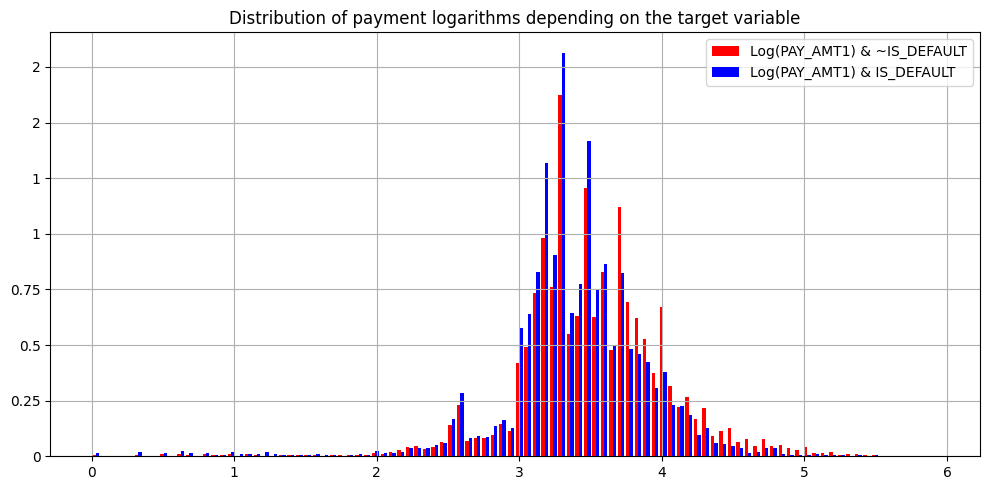

In [34]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5))

pyspark_dist_explore.hist(ax, [pay_0, pay_1], color=['red', 'blue'], bins=100, density=True)

ax.set_title('Distribution of payment logarithms depending on the target variable')
ax.grid(True)
ax.legend()

fig.tight_layout()
plt.show()

##### `Native algorithm`

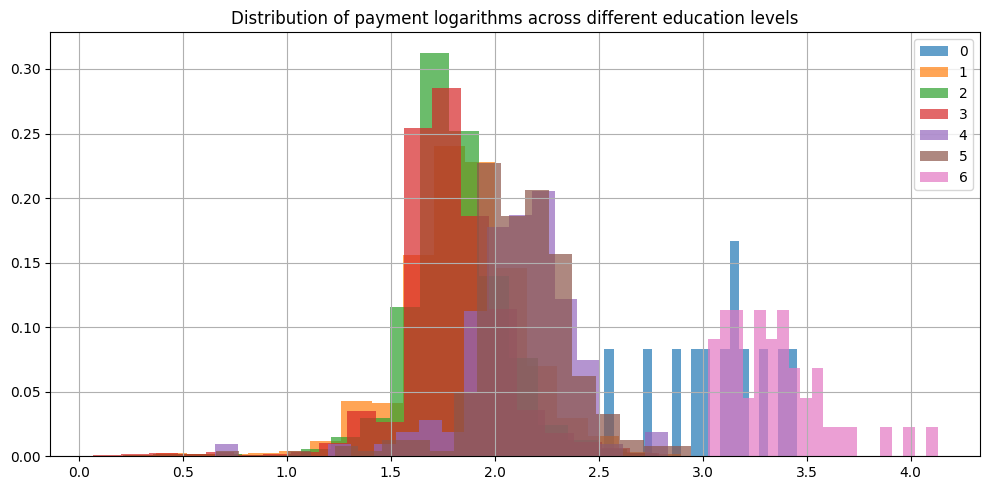

In [35]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5))

ed_levels = data.select('EDUCATION').distinct().collect()
for ed_level, color in zip(sorted(ed_levels), plt.cm.tab10.colors):
    buckets, histogram = (
        data
            .filter(
                (data.EDUCATION == ed_level.EDUCATION) & (data.PAY_AMT1 > 0)
            )
            .select(F.log10('PAY_AMT1').alias('log_PAY_AMT1'))
            .rdd
            .map(lambda x: x.log_PAY_AMT1)
            .histogram(20)
    )
    buckets = np.array(buckets)
    histogram = np.array(histogram)

    buckets = (buckets[:-1] + buckets[1]) / 2
    histogram = histogram / np.sum(histogram)

    ax.bar(buckets, histogram, width=(buckets[1] - buckets[0]), label=ed_level.EDUCATION, alpha=0.7, color=color)

ax.set_title('Distribution of payment logarithms across different education levels')
ax.legend()
ax.grid(True)

fig.tight_layout()
plt.show()

## `Data Preprocessing and Model Training`

In [36]:
data = data.drop('ID')
data_train, data_test = data.randomSplit([0.7, 0.3], seed=6417)

In [37]:
from pyspark.ml import Pipeline

from pyspark.ml.feature import VectorAssembler, OneHotEncoder, StandardScaler

from pyspark.ml.regression import LinearRegression
from pyspark.ml.classification import LogisticRegression, RandomForestClassifier

In [38]:
label_column = 'IS_DEFAULT'
feature_columns = [_ for _ in data.columns if _ != label_column]
feature_columns

['LIMIT_BAL',
 'SEX',
 'EDUCATION',
 'MARRIAGE',
 'AGE',
 'PAY_0',
 'PAY_2',
 'PAY_3',
 'PAY_4',
 'PAY_5',
 'PAY_6',
 'BILL_AMT1',
 'BILL_AMT2',
 'BILL_AMT3',
 'BILL_AMT4',
 'BILL_AMT5',
 'BILL_AMT6',
 'PAY_AMT1',
 'PAY_AMT2',
 'PAY_AMT3',
 'PAY_AMT4',
 'PAY_AMT5',
 'PAY_AMT6']

In [39]:
assembler = VectorAssembler(inputCols=feature_columns, outputCol='features')
scaler = StandardScaler(inputCol='features', outputCol='features_scaled', withMean=True, withStd=True)
logistic_regressor = LogisticRegression(featuresCol='features_scaled', labelCol=label_column, predictionCol='prediction')
linear_regression = LinearRegression(featuresCol='features_scaled', labelCol=label_column, predictionCol='prediction_reg')

pipe = Pipeline(stages=[
    assembler,
    scaler,
    logistic_regressor,
    linear_regression
])
print(assembler, scaler, logistic_regressor, pipe, sep='\n')
print(type(assembler), type(scaler), type(logistic_regressor), type(pipe), sep='\n')

VectorAssembler_f95186d39f41
StandardScaler_19878c64d3d7
LogisticRegression_d72d79f061b0
Pipeline_9bd5fdf67ba6
<class 'pyspark.ml.feature.VectorAssembler'>
<class 'pyspark.ml.feature.StandardScaler'>
<class 'pyspark.ml.classification.LogisticRegression'>
<class 'pyspark.ml.pipeline.Pipeline'>


In [40]:
pipe_model = pipe.fit(data_train)
pipe_model

25/11/10 22:31:08 WARN Instrumentation: [6ee062b7] regParam is zero, which might cause numerical instability and overfitting.
25/11/10 22:31:08 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.lapack.JNILAPACK


PipelineModel_02ef28ac3c36

In [41]:
print(pipe.stages, sep='\n')
print(*pipe_model.stages, sep='\n')

Pipeline_9bd5fdf67ba6__stages
VectorAssembler_f95186d39f41
StandardScalerModel: uid=StandardScaler_19878c64d3d7, numFeatures=23, withMean=true, withStd=true
LogisticRegressionModel: uid=LogisticRegression_d72d79f061b0, numClasses=2, numFeatures=23
LinearRegressionModel: uid=LinearRegression_ed8c517529fc, numFeatures=23


In [42]:
pipe_model.transform(data_train).limit(3).toPandas()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,PAY_AMT4,PAY_AMT5,PAY_AMT6,IS_DEFAULT,features,features_scaled,rawPrediction,probability,prediction,prediction_reg
0,10000.0,1,1,1,38,-1,-1,2,0,0,...,1100.0,0.0,1000.0,1,"[10000.0, 1.0, 1.0, 1.0, 38.0, -1.0, -1.0, 2.0...","[-1.2106245607528727, -1.2380925925385027, -1....","[1.3298376762861168, -1.3298376762861168]","[0.7908137832737795, 0.2091862167262205]",0.0,0.217064
1,10000.0,1,1,1,40,2,-1,-1,-2,-2,...,0.0,0.0,0.0,1,"(10000.0, 1.0, 1.0, 1.0, 40.0, 2.0, -1.0, -1.0...","[-1.2106245607528727, -1.2380925925385027, -1....","[-0.037886150540415775, 0.037886150540415775]","[0.49052959512481065, 0.5094704048751894]",1.0,0.460260
2,10000.0,1,1,1,42,4,3,2,2,2,...,0.0,359.0,331.0,0,"[10000.0, 1.0, 1.0, 1.0, 42.0, 4.0, 3.0, 2.0, ...","[-1.2106245607528727, -1.2380925925385027, -1....","[-2.0617333212678286, 2.0617333212678286]","[0.11287215259825212, 0.8871278474017479]",1.0,0.802989


In [43]:
pipe_model.transform(data_test).limit(3).toPandas()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,PAY_AMT4,PAY_AMT5,PAY_AMT6,IS_DEFAULT,features,features_scaled,rawPrediction,probability,prediction,prediction_reg
0,10000.0,1,1,1,41,0,0,3,2,2,...,1002.0,0.0,500.0,0,"[10000.0, 1.0, 1.0, 1.0, 41.0, 0.0, 0.0, 3.0, ...","[-1.2106245607528727, -1.2380925925385027, -1....","[0.45998406971393124, -0.45998406971393124]","[0.6130103970258782, 0.38698960297412177]",0.0,0.362307
1,10000.0,1,1,2,22,0,0,0,0,0,...,1200.0,0.0,0.0,0,"[10000.0, 1.0, 1.0, 2.0, 22.0, 0.0, 0.0, 0.0, ...","[-1.2106245607528727, -1.2380925925385027, -1....","[1.0388219404112757, -1.0388219404112757]","[0.7386226347405451, 0.2613773652594549]",0.0,0.270235
2,10000.0,1,1,2,22,2,2,2,0,0,...,1100.0,0.0,500.0,1,"[10000.0, 1.0, 1.0, 2.0, 22.0, 2.0, 2.0, 2.0, ...","[-1.2106245607528727, -1.2380925925385027, -1....","[-0.42413278131321586, 0.42413278131321586]","[0.3955282360336502, 0.6044717639663497]",1.0,0.525330


## `Quality Evaluation`

In [44]:
summary = pipe_model.stages[-2].summary
summary.accuracy, summary.areaUnderROC, summary.precisionByLabel, summary.recallByLabel

(0.8085441527446301,
 0.7236303702043676,
 [0.8162098103874691, 0.7120622568093385],
 [0.9727356463002763, 0.23536977491961414])

In [45]:
summary = pipe_model.stages[-1].summary
summary.r2, summary.meanSquaredError

(0.12251521844731605, 0.15188362346827863)

In [46]:
from pyspark.ml.evaluation import (
    BinaryClassificationEvaluator,
    MulticlassClassificationEvaluator
)

In [47]:
evaluator = BinaryClassificationEvaluator(
    labelCol=label_column,
    metricName='areaUnderROC'
)
print('ROC AUC train/test: {0:.3f}/{1:.3f}'.format(
    evaluator.evaluate(pipe_model.transform(data_train)),
    evaluator.evaluate(pipe_model.transform(data_test))
))

ROC AUC train/test: 0.724/0.726


## `Hyperparameter Tuning`

In [48]:
from pyspark.ml.tuning import ParamGridBuilder, TrainValidationSplit

In [49]:
logistic_regressor.maxIter

Param(parent='LogisticRegression_d72d79f061b0', name='maxIter', doc='max number of iterations (>= 0).')

In [50]:
param_grid = (
    ParamGridBuilder()
        .addGrid(logistic_regressor.maxIter, [100])
        .addGrid(logistic_regressor.regParam, [1e-2, 1e-1, 1e-0, 1e-1])
        .addGrid(logistic_regressor.elasticNetParam, [0.0, 0.5, 1.0])
        .build()
)
len(param_grid), param_grid[0]

(12,
 {Param(parent='LogisticRegression_d72d79f061b0', name='maxIter', doc='max number of iterations (>= 0).'): 100,
  Param(parent='LogisticRegression_d72d79f061b0', name='regParam', doc='regularization parameter (>= 0).'): 0.01,
  Param(parent='LogisticRegression_d72d79f061b0', name='elasticNetParam', doc='the ElasticNet mixing parameter, in range [0, 1]. For alpha = 0, the penalty is an L2 penalty. For alpha = 1, it is an L1 penalty.'): 0.0})

In [51]:
tvs = TrainValidationSplit(
    estimator=pipe,
    estimatorParamMaps=param_grid,
    evaluator=evaluator,
    trainRatio=0.8,
    seed=6417,
    parallelism=3
)

tvs_model = tvs.fit(data)
tvs_model

25/11/10 22:31:13 WARN Instrumentation: [63e6dfb8] regParam is zero, which might cause numerical instability and overfitting.
25/11/10 22:31:13 WARN Instrumentation: [acdc52cf] regParam is zero, which might cause numerical instability and overfitting.
25/11/10 22:31:13 WARN Instrumentation: [197531e4] regParam is zero, which might cause numerical instability and overfitting.
25/11/10 22:31:14 WARN Instrumentation: [6bedcab7] regParam is zero, which might cause numerical instability and overfitting.
25/11/10 22:31:14 WARN Instrumentation: [c54da81a] regParam is zero, which might cause numerical instability and overfitting.
25/11/10 22:31:14 WARN Instrumentation: [48067e2a] regParam is zero, which might cause numerical instability and overfitting.
25/11/10 22:31:15 WARN Instrumentation: [5aa51df1] regParam is zero, which might cause numerical instability and overfitting.
25/11/10 22:31:15 WARN Instrumentation: [1b1631b2] regParam is zero, which might cause numerical instability and overf

TrainValidationSplitModel_9e64a04df91f

In [52]:
print('ROC AUC train/test: {0:.3f}/{1:.3f}'.format(
    evaluator.evaluate(tvs_model.transform(data_train)),
    evaluator.evaluate(tvs_model.transform(data_test))
))

ROC AUC train/test: 0.722/0.725


In [53]:
tvs_model.bestModel.stages[-1].extractParamMap()

{Param(parent='LinearRegression_ed8c517529fc', name='aggregationDepth', doc='suggested depth for treeAggregate (>= 2).'): 2,
 Param(parent='LinearRegression_ed8c517529fc', name='elasticNetParam', doc='the ElasticNet mixing parameter, in range [0, 1]. For alpha = 0, the penalty is an L2 penalty. For alpha = 1, it is an L1 penalty.'): 0.0,
 Param(parent='LinearRegression_ed8c517529fc', name='epsilon', doc='The shape parameter to control the amount of robustness. Must be > 1.0. Only valid when loss is huber'): 1.35,
 Param(parent='LinearRegression_ed8c517529fc', name='featuresCol', doc='features column name.'): 'features_scaled',
 Param(parent='LinearRegression_ed8c517529fc', name='fitIntercept', doc='whether to fit an intercept term.'): True,
 Param(parent='LinearRegression_ed8c517529fc', name='labelCol', doc='label column name.'): 'IS_DEFAULT',
 Param(parent='LinearRegression_ed8c517529fc', name='loss', doc='The loss function to be optimized. Supported options: squaredError, huber.'): '

## `Example. Random Forest`

In [54]:
label_column = 'IS_DEFAULT'
feature_columns = [_ for _ in data.columns if _ not in {label_column, 'EDUCATION'}]

In [55]:
ohe_encoder = OneHotEncoder(inputCols=['EDUCATION'], outputCols=['EDUCATION_OHE'])
rf_assembler = VectorAssembler(inputCols=feature_columns + ['EDUCATION_OHE'], outputCol='features')
random_forest = RandomForestClassifier(featuresCol='features', labelCol=label_column, predictionCol='prediction')

rf_pipe = Pipeline(stages=[ohe_encoder, rf_assembler, random_forest])
ohe_encoder, rf_assembler, random_forest, rf_pipe

(OneHotEncoder_cbb37334fdf8,
 VectorAssembler_ffaf882d6120,
 RandomForestClassifier_2948d5a80651,
 Pipeline_67ee07aa2569)

In [56]:
rf_pipe_model = rf_pipe.fit(data_train)
rf_pipe_model.transform(data_train).limit(3).toPandas()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,IS_DEFAULT,EDUCATION_OHE,features,rawPrediction,probability,prediction
0,10000.0,1,1,1,38,-1,-1,2,0,0,...,500.0,1100.0,0.0,1000.0,1,"(0.0, 1.0, 0.0, 0.0, 0.0, 0.0)","[10000.0, 1.0, 1.0, 38.0, -1.0, -1.0, 2.0, 0.0...","[15.316280331389699, 4.6837196686102995]","[0.7658140165694849, 0.23418598343051497]",0.0
1,10000.0,1,1,1,40,2,-1,-1,-2,-2,...,0.0,0.0,0.0,0.0,1,"(0.0, 1.0, 0.0, 0.0, 0.0, 0.0)","(10000.0, 1.0, 1.0, 40.0, 2.0, -1.0, -1.0, -2....","[8.92292092043682, 11.07707907956318]","[0.446146046021841, 0.5538539539781591]",1.0
2,10000.0,1,1,1,42,4,3,2,2,2,...,2000.0,0.0,359.0,331.0,0,"(0.0, 1.0, 0.0, 0.0, 0.0, 0.0)","[10000.0, 1.0, 1.0, 42.0, 4.0, 3.0, 2.0, 2.0, ...","[6.4212871263924995, 13.578712873607499]","[0.321064356319625, 0.678935643680375]",1.0


In [57]:
print('ROC AUC train/test: {0:.3f}/{1:.3f}'.format(
    evaluator.evaluate(rf_pipe_model.transform(data_train)),
    evaluator.evaluate(rf_pipe_model.transform(data_test))
))

ROC AUC train/test: 0.776/0.768


In [58]:
rf_pipe_model.stages[-1]

RandomForestClassificationModel: uid=RandomForestClassifier_2948d5a80651, numTrees=20, numClasses=2, numFeatures=28

## `Example. Text Data`

In [59]:
path = './tweets'

! mkdir $path
! wget -O "$path/negative.csv" "https://www.dropbox.com/s/r6u59ljhhjdg6j0/negative.csv?dl=0"
! wget -O "$path/positive.csv" "https://www.dropbox.com/s/fnpq3z4bcnoktiv/positive.csv?dl=0"

--2025-11-10 22:31:22--  https://www.dropbox.com/s/r6u59ljhhjdg6j0/negative.csv?dl=0
Resolving www.dropbox.com (www.dropbox.com)... 162.125.66.18, 2620:100:6022:18::a27d:4212
Connecting to www.dropbox.com (www.dropbox.com)|162.125.66.18|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://www.dropbox.com/scl/fi/wui0xz78kpna56690uej4/negative.csv?rlkey=309xeou9u3rtbejw9stb13wfr&dl=0 [following]
--2025-11-10 22:31:22--  https://www.dropbox.com/scl/fi/wui0xz78kpna56690uej4/negative.csv?rlkey=309xeou9u3rtbejw9stb13wfr&dl=0
Reusing existing connection to www.dropbox.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://uc58a76dd78b798d23cd3f2ce959.dl.dropboxusercontent.com/cd/0/inline/C07s5xvRyAwHXRT6CAgPefdUuukM310if2S-uvVAgYYRzdzvD2GsBxZJ1BS3cArkU1e9HXCzs-tnrMwlX36QD8J1ljy4BH1QVE-p1u4AApWtKB9GYK_0OdkDMh-KRLWWRTg/file# [following]
--2025-11-10 22:31:23--  https://uc58a76dd78b798d23cd3f2ce959.dl.dropboxusercontent.com/cd/0/inline/C07s

In [60]:
# Set the paths to files from the dataset
file_type = "csv"
infer_schema = "false"
first_row_is_header = "false"
delimiter = ";"

text_data_negative = (
    spark.read.format(file_type)
      .option("inferSchema", infer_schema)
      .option("header", first_row_is_header)
      .option("sep", delimiter)
      .load([
          f"{path}/negative.csv",
        ])
)
text_data_positive = (
    spark.read.format(file_type)
      .option("inferSchema", infer_schema)
      .option("header", first_row_is_header)
      .option("sep", delimiter)
      .load([
          f"{path}/positive.csv"
        ])
)

In [61]:
display(text_data_negative.limit(3).toPandas())
display(text_data_positive.limit(3).toPandas())

,_c0,_c1,_c2,_c3,_c4,_c5,_c6,_c7,_c8,_c9,_c10,_c11
0,408906762813579264,1386325944,dugarchikbellko,на работе был полный пиддес :| и так каждое за...,-1,0,0,0,8064,111,94,2
1,408906818262687744,1386325957,nugemycejela,"Коллеги сидят рубятся в Urban terror, а я из-з...",-1,0,0,0,26,42,39,0
2,408906858515398656,1386325966,4post21,@elina_4post как говорят обещаного три года жд...,-1,0,0,0,718,49,249,0


,_c0,_c1,_c2,_c3,_c4,_c5,_c6,_c7,_c8,_c9,_c10,_c11
0,408906692374446080,1386325927,pleease_shut_up,"@first_timee хоть я и школота, но поверь, у на...",1,0,0,0,7569,62,61,0
1,408906692693221377,1386325927,alinakirpicheva,"Да, все-таки он немного похож на него. Но мой ...",1,0,0,0,11825,59,31,2
2,408906695083954177,1386325927,EvgeshaRe,RT @KatiaCheh: Ну ты идиотка) я испугалась за ...,1,0,1,0,1273,26,27,0


In [62]:
text_data_negative = text_data_negative.select('_c3').withColumnRenamed('_c3', 'text').withColumn('label', F.lit(0))
text_data_positive = text_data_positive.select('_c3').withColumnRenamed('_c3', 'text').withColumn('label', F.lit(1))
text_data = text_data_negative.union(text_data_positive).dropna()

text_data.sample(3e-5).show(truncate=False)

+-------------------------------------------------------------------------------------------------------------+-----+
|text                                                                                                         |label|
+-------------------------------------------------------------------------------------------------------------+-----+
|RT @bywopyxawepy: ххх:Блин, у меня по лицу от косметики аллергические пятна пошли! =( ууу:Кошмар, и че делать|0    |
|ленечка нуб — арина не смешно( http://t.co/ylKp72il60                                                        |0    |
|@_tomo_king у меня вообще новогоднего настроения нету, тут это у меня..депрессия :(( воот ,                  |0    |
|меня обидел человек который мне очень нравиться=((((((((( да ище испортил мне вечер                          |0    |
|0                                                                                                            |0    |
|0                                                      

In [63]:
from pyspark.ml.feature import Tokenizer, NGram, HashingTF, IDF
from pyspark.ml.classification import NaiveBayes

In [64]:
import mlflow
import mlflow.spark

mlflow.set_tracking_uri("sqlite:///mlflow.db")
mlflow.set_experiment("spark-text-pipeline")
# mlflow ui --backend-store-uri sqlite:///mlflow.db --port 5000;

2025/11/10 22:31:30 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2025/11/10 22:31:30 INFO mlflow.store.db.utils: Updating database tables
2025-11-10 22:31:30 INFO  [alembic.runtime.migration] Context impl SQLiteImpl.
2025-11-10 22:31:30 INFO  [alembic.runtime.migration] Will assume non-transactional DDL.
2025-11-10 22:31:30 INFO  [alembic.runtime.migration] Running upgrade  -> 451aebb31d03, add metric step
2025-11-10 22:31:30 INFO  [alembic.runtime.migration] Running upgrade 451aebb31d03 -> 90e64c465722, migrate user column to tags
2025-11-10 22:31:30 INFO  [alembic.runtime.migration] Running upgrade 90e64c465722 -> 181f10493468, allow nulls for metric values
2025-11-10 22:31:30 INFO  [alembic.runtime.migration] Running upgrade 181f10493468 -> df50e92ffc5e, Add Experiment Tags Table
2025-11-10 22:31:30 INFO  [alembic.runtime.migration] Running upgrade df50e92ffc5e -> 7ac759974ad8, Update run tags with larger limit
2025-11-10 22:31:30 INFO  [alembic.runtime.mig

<Experiment: artifact_location=('/mnt/c/Users/nahod/Documents/CodeBlocks/MSU/Hadoop/Industrial-Machine-Learning-on-Hadoop-and-Spark/Seminars/Seminar '
 '08/mlruns/1'), creation_time=1762810292596, experiment_id='1', last_update_time=1762810292596, lifecycle_stage='active', name='spark-text-pipeline', tags={}>

In [65]:
text_pipe = Pipeline(stages=[
    Tokenizer(inputCol='text', outputCol='tokens'),
    NGram(inputCol='tokens', outputCol='ngrams', n=2),
    HashingTF(inputCol='ngrams', outputCol='tf'),
    IDF(inputCol='tf', outputCol='idf'),
    VectorAssembler(inputCols=['tf', 'idf'], outputCol='features'),
    NaiveBayes(featuresCol='features', labelCol='label')
])

In [66]:
with mlflow.start_run(run_name="Feature Pipeline"):
    text_pipe_model = text_pipe.fit(text_data)

    # Log the entire pipeline
    model_info = mlflow.spark.log_model(
        spark_model=text_pipe_model, artifact_path="spark-text-pipeline"
    )

    # Log parameters manually
    mlflow.log_params(
        {
            "num_features": text_pipe_model.stages[2].getNumFeatures(),
        }
    )

25/11/10 22:31:34 WARN DAGScheduler: Broadcasting large task binary with size 30.6 MiB
25/11/10 22:31:38 WARN DAGScheduler: Broadcasting large task binary with size 30.6 MiB
25/11/10 22:31:39 WARN TaskSetManager: Stage 1519 contains a task of very large size (4190 KiB). The maximum recommended task size is 1000 KiB.
25/11/10 22:31:40 WARN TaskSetManager: Stage 1522 contains a task of very large size (8370 KiB). The maximum recommended task size is 1000 KiB.


In [67]:
text_pipe_model.transform(text_data).limit(3).toPandas()

25/11/10 22:31:52 WARN DAGScheduler: Broadcasting large task binary with size 12.1 MiB


,text,label,tokens,ngrams,tf,idf,features,rawPrediction,probability,prediction
0,на работе был полный пиддес :| и так каждое за...,0,"[на, работе, был, полный, пиддес, :|, и, так, ...","[на работе, работе был, был полный, полный пид...","(0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","(0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","(0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[-1967.08547000446, -1985.1947238238504]","[0.9999999863462801, 1.3653719889781722e-08]",0.0
1,"Коллеги сидят рубятся в Urban terror, а я из-з...",0,"[коллеги, сидят, рубятся, в, urban, terror,, а...","[коллеги сидят, сидят рубятся, рубятся в, в ur...","(0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","(0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","(0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[-1536.899562052501, -1695.331439735471]","[1.0, 1.562822894282169e-69]",0.0
2,@elina_4post как говорят обещаного три года жд...,0,"[@elina_4post, как, говорят, обещаного, три, г...","[@elina_4post как, как говорят, говорят обещан...","(0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","(0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","(0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[-839.4052796735651, -857.270362723404]","[0.9999999825701759, 1.74298241347285e-08]",0.0


In [68]:
evaluator_roc_auc = BinaryClassificationEvaluator(
    labelCol='label',
    metricName='areaUnderROC'
)
evaluator_accuracy = MulticlassClassificationEvaluator(
    labelCol='label',
    metricName='accuracy'
)
print('ROC AUC: {0:.3f}, Accuracy: {1:.3f}'.format(
    evaluator_roc_auc.evaluate(text_pipe_model.transform(text_data)),
    evaluator_accuracy.evaluate(text_pipe_model.transform(text_data)),
))

25/11/10 22:31:55 WARN DAGScheduler: Broadcasting large task binary with size 38.6 MiB
25/11/10 22:31:59 WARN DAGScheduler: Broadcasting large task binary with size 38.6 MiB


ROC AUC: 0.486, Accuracy: 0.849


## `Example. Some EDA for Data from the Project (M5 Forecasting)`

In [69]:
path = "./m5-forecasting-accuracy"
! kaggle competitions download -c m5-forecasting-accuracy
! unzip m5-forecasting-accuracy.zip -d $path
! rm -rf m5-forecasting-accuracy.zip

 52%|████████████████████▍                  | 24.0M/45.8M [00:00<00:00, 245MB/s]
100%|███████████████████████████████████████| 45.8M/45.8M [00:00<00:00, 249MB/s]
Archive:  m5-forecasting-accuracy.zip
  inflating: ./m5-forecasting-accuracy/calendar.csv  
  inflating: ./m5-forecasting-accuracy/sales_train_evaluation.csv  
  inflating: ./m5-forecasting-accuracy/sales_train_validation.csv  
  inflating: ./m5-forecasting-accuracy/sample_submission.csv  
  inflating: ./m5-forecasting-accuracy/sell_prices.csv  


In [70]:
file_calendar = f"{path}/calendar.csv"
file_validation = f"{path}/sales_train_validation.csv"
file_evaluation = f"{path}/sales_train_evaluation.csv"
file_prices = f"{path}/sell_prices.csv"
file_calendar = f"{path}/calendar.csv"

file_type = "csv"
infer_schema = "true"
first_row_is_header = "true"
delimiter = ","

df_validation = (
    spark.read.format(file_type)
      .option("inferSchema", infer_schema)
      .option("header", first_row_is_header)
      .option("sep", delimiter)
      .load(file_validation)
)
df_evaluation = (
    spark.read.format(file_type)
      .option("inferSchema", infer_schema)
      .option("header", first_row_is_header)
      .option("sep", delimiter)
      .load(file_evaluation)
)
df_prices = (
    spark.read.format(file_type)
      .option("inferSchema", infer_schema)
      .option("header", first_row_is_header)
      .option("sep", delimiter)
      .load(file_prices)
)
df_calendar = (
    spark.read.format(file_type)
      .option("inferSchema", infer_schema)
      .option("header", first_row_is_header)
      .option("sep", delimiter)
      .load(file_calendar)
)

In [71]:
df_evaluation.limit(5).toPandas()

,id,item_id,dept_id,cat_id,store_id,state_id,d_1,d_2,d_3,d_4,...,d_1932,d_1933,d_1934,d_1935,d_1936,d_1937,d_1938,d_1939,d_1940,d_1941
0,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,2,4,0,0,0,0,3,3,0,1
1,HOBBIES_1_002_CA_1_evaluation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,1,2,1,1,0,0,0,0,0
2,HOBBIES_1_003_CA_1_evaluation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,0,2,0,0,0,2,3,0,1
3,HOBBIES_1_004_CA_1_evaluation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,1,0,4,0,1,3,0,2,6
4,HOBBIES_1_005_CA_1_evaluation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,0,0,2,1,0,0,2,1,0


Let’s find out whether there is a difference in product demand depending on the day of the week. To do this, we’ll calculate the total demand for each day, then aggregate it by weekdays and plot it.

Let’s take the columns that contain demand for a specific day:

In [72]:
day_columns = [column for column in df_evaluation.columns if column.startswith('d_')]
day_columns[:10]

['d_1', 'd_2', 'd_3', 'd_4', 'd_5', 'd_6', 'd_7', 'd_8', 'd_9', 'd_10']

Calculate the total demand for all products for each day:

In [73]:
df_evaluation_agg = df_evaluation.select(
    *[
        F.sum(column).alias(column)
        for column in day_columns
    ]
).cache()

df_evaluation_agg.toPandas()

25/11/10 22:32:21 WARN DAGScheduler: Broadcasting large task binary with size 1264.0 KiB
25/11/10 22:32:29 WARN DAGScheduler: Broadcasting large task binary with size 2.8 MiB
25/11/10 22:32:33 WARN DAGScheduler: Broadcasting large task binary with size 2.9 MiB


,d_1,d_2,d_3,d_4,d_5,d_6,d_7,d_8,d_9,d_10,...,d_1932,d_1933,d_1934,d_1935,d_1936,d_1937,d_1938,d_1939,d_1940,d_1941
0,32631,31749,23783,25412,19146,29211,28010,37932,32736,25572,...,44073,54308,59921,42362,38777,37096,36963,42552,51518,54338


To perform aggregation by weekdays, we need to determine for each day which weekday it corresponds to. This information is available in the calendar table:

In [74]:
df_calendar.limit(10).toPandas()

,date,wm_yr_wk,weekday,wday,month,year,d,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
0,2011-01-29,11101,Saturday,1,1,2011,d_1,None,None,None,None,0,0,0
1,2011-01-30,11101,Sunday,2,1,2011,d_2,None,None,None,None,0,0,0
2,2011-01-31,11101,Monday,3,1,2011,d_3,None,None,None,None,0,0,0
3,2011-02-01,11101,Tuesday,4,2,2011,d_4,None,None,None,None,1,1,0
4,2011-02-02,11101,Wednesday,5,2,2011,d_5,None,None,None,None,1,0,1
5,2011-02-03,11101,Thursday,6,2,2011,d_6,None,None,None,None,1,1,1
6,2011-02-04,11101,Friday,7,2,2011,d_7,None,None,None,None,1,0,0
7,2011-02-05,11102,Saturday,1,2,2011,d_8,None,None,None,None,1,1,1
8,2011-02-06,11102,Sunday,2,2,2011,d_9,SuperBowl,Sporting,None,None,1,1,1
9,2011-02-07,11102,Monday,3,2,2011,d_10,None,None,None,None,1,1,0


To add information about the weekday to the aggregated demand data, we need to transpose the demand table and then perform a join with the calendar.

In [75]:
# Perform an unpivot by constructing the required expression. The old way:

column_exprs = []
for column in day_columns:
    column_exprs += [f'"{column}"', f'{column}']

unpivot_expr = 'stack({0}, {1}) as (Day, Count)'.format(
    len(column_exprs) // 2,
    ', '.join(column_exprs)
)
print(unpivot_expr[:60], '...', unpivot_expr[-71:])

df_evaluation_agg_unpivot = df_evaluation_agg.select(F.expr(unpivot_expr)).cache()
df_evaluation_agg_unpivot.limit(10).toPandas()

stack(1941, "d_1", d_1, "d_2", d_2, "d_3", d_3, "d_4", d_4,  ... , "d_1939", d_1939, "d_1940", d_1940, "d_1941", d_1941) as (Day, Count)


25/11/10 22:32:36 WARN DAGScheduler: Broadcasting large task binary with size 3.1 MiB
25/11/10 22:32:36 WARN DAGScheduler: Broadcasting large task binary with size 3.1 MiB


,Day,Count
0,d_1,32631
1,d_2,31749
2,d_3,23783
3,d_4,25412
4,d_5,19146
5,d_6,29211
6,d_7,28010
7,d_8,37932
8,d_9,32736
9,d_10,25572


In [76]:
# The new way:
df_evaluation_agg_unpivot = df_evaluation_agg.unpivot(
    ids=[], values=day_columns, variableColumnName='Day', valueColumnName='Count'
).cache()

df_evaluation_agg_unpivot.limit(10).toPandas()

25/11/10 22:32:37 WARN DAGScheduler: Broadcasting large task binary with size 3.1 MiB
25/11/10 22:32:42 WARN DAGScheduler: Broadcasting large task binary with size 3.1 MiB


,Day,Count
0,d_1,32631
1,d_2,31749
2,d_3,23783
3,d_4,25412
4,d_5,19146
5,d_6,29211
6,d_7,28010
7,d_8,37932
8,d_9,32736
9,d_10,25572


Perform the join and keep only the necessary columns:

In [77]:
df_evaluation_agg_unpivot_with_wday = (
    df_evaluation_agg_unpivot
        .join(df_calendar, on=df_calendar.d == df_evaluation_agg_unpivot.Day)
        .select('Day', 'Count', 'weekday', 'wday')
).cache()
df_evaluation_agg_unpivot_with_wday.limit(5).toPandas()

25/11/10 22:32:43 WARN DAGScheduler: Broadcasting large task binary with size 3.1 MiB
25/11/10 22:32:44 WARN DAGScheduler: Broadcasting large task binary with size 3.1 MiB


,Day,Count,weekday,wday
0,d_1,32631,Saturday,1
1,d_2,31749,Sunday,2
2,d_3,23783,Monday,3
3,d_4,25412,Tuesday,4
4,d_5,19146,Wednesday,5


Now perform aggregation by weekdays:

In [78]:
count_per_weekday = (
    df_evaluation_agg_unpivot_with_wday
        .groupBy('weekday')
        .agg(
            F.sum('Count').alias('Count'),
            F.first('wday').alias('wday')
        )
        .collect()
)
count_per_weekday

25/11/10 22:32:45 WARN DAGScheduler: Broadcasting large task binary with size 3.1 MiB


[Row(weekday='Wednesday', Count=8346126, wday=5),
 Row(weekday='Tuesday', Count=8448634, wday=4),
 Row(weekday='Friday', Count=9517020, wday=7),
 Row(weekday='Thursday', Count=8398928, wday=6),
 Row(weekday='Saturday', Count=11594343, wday=1),
 Row(weekday='Monday', Count=9139596, wday=3),
 Row(weekday='Sunday', Count=11482526, wday=2)]

Display the resulting demand by weekdays on a chart:

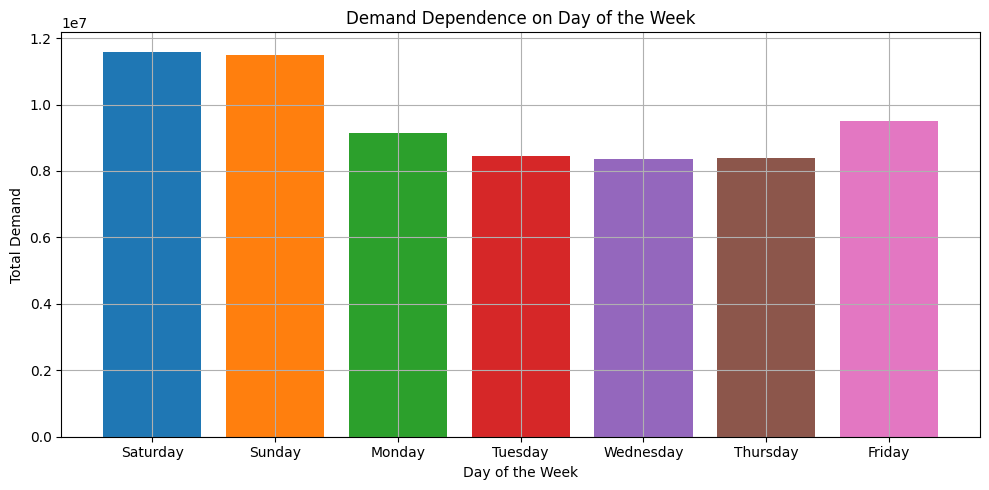

In [79]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5))

for row in sorted(count_per_weekday, key=lambda row: row.wday):
    ax.bar(row.weekday, row.Count)

ax.grid(True)

ax.set_xlabel('Day of the Week')
ax.set_ylabel('Total Demand')
ax.set_title('Demand Dependence on Day of the Week')

fig.tight_layout()
plt.show()

Explore the monthly and yearly trend by performing aggregation by months and days of the year:

In [80]:
df_evaluation_agg_unpivot_with_date = (
    df_evaluation_agg_unpivot
        .join(df_calendar, on=df_calendar.d == df_evaluation_agg_unpivot.Day)
        .select('Day', 'Count', 'month', F.dayofyear('date').alias('day_of_year'))
).cache()
df_evaluation_agg_unpivot_with_date.limit(5).toPandas()

25/11/10 22:32:45 WARN DAGScheduler: Broadcasting large task binary with size 3.1 MiB
25/11/10 22:32:46 WARN DAGScheduler: Broadcasting large task binary with size 3.1 MiB


,Day,Count,month,day_of_year
0,d_1,32631,1,29
1,d_2,31749,1,30
2,d_3,23783,1,31
3,d_4,25412,2,32
4,d_5,19146,2,33


In [81]:
count_per_month = (
    df_evaluation_agg_unpivot_with_date
        .groupBy('month')
        .agg(F.mean('Count').alias('Count'))
        .collect()
)
count_per_month

25/11/10 22:32:47 WARN DAGScheduler: Broadcasting large task binary with size 3.1 MiB


[Row(month=12, Count=32980.46451612903),
 Row(month=1, Count=33832.34810126582),
 Row(month=6, Count=35001.41333333333),
 Row(month=3, Count=34339.83870967742),
 Row(month=5, Count=34085.19209039548),
 Row(month=9, Count=35479.26),
 Row(month=4, Count=34432.183333333334),
 Row(month=8, Count=35946.645161290326),
 Row(month=7, Count=35122.41935483871),
 Row(month=10, Count=34713.47741935484),
 Row(month=11, Count=33290.82666666667),
 Row(month=2, Count=34644.64117647059)]

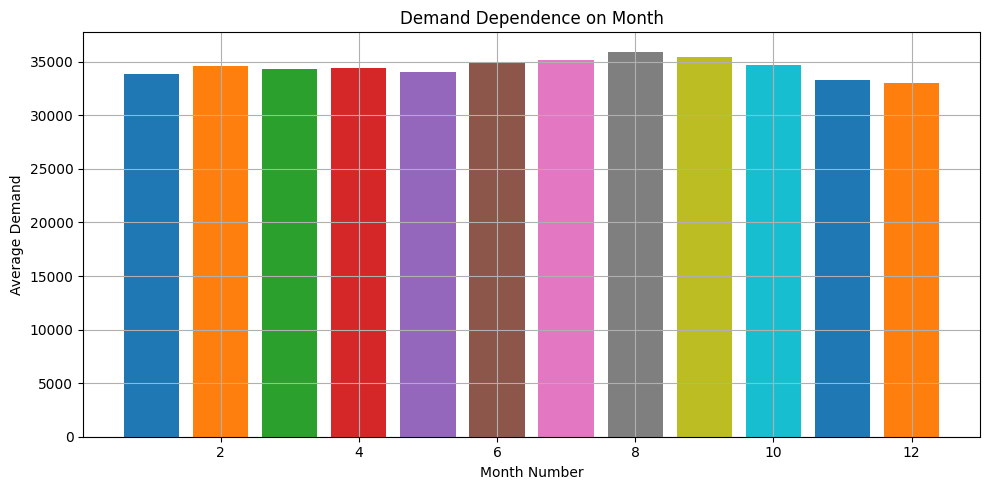

In [82]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5))

for row in sorted(count_per_month, key=lambda row: row.month):
    ax.bar(row.month, row.Count)

ax.grid(True)

ax.set_xlabel('Month Number')
ax.set_ylabel('Average Demand')
ax.set_title('Demand Dependence on Month')

fig.tight_layout()
plt.show()

In [83]:
count_per_day = (
    df_evaluation_agg_unpivot_with_date
        .groupBy('day_of_year')
        .agg(
            F.mean('Count').alias('Count'),
            F.first('month').alias('month')
        )
        .collect()
)
count_per_day[:10]

25/11/10 22:32:48 WARN DAGScheduler: Broadcasting large task binary with size 3.1 MiB


[Row(day_of_year=148, Count=29400.6, month=5),
 Row(day_of_year=243, Count=34618.6, month=8),
 Row(day_of_year=31, Count=35634.333333333336, month=1),
 Row(day_of_year=85, Count=33103.666666666664, month=3),
 Row(day_of_year=137, Count=34974.333333333336, month=5),
 Row(day_of_year=251, Count=36462.4, month=9),
 Row(day_of_year=65, Count=36754.666666666664, month=3),
 Row(day_of_year=53, Count=33292.333333333336, month=2),
 Row(day_of_year=255, Count=36747.4, month=9),
 Row(day_of_year=133, Count=34860.166666666664, month=5)]

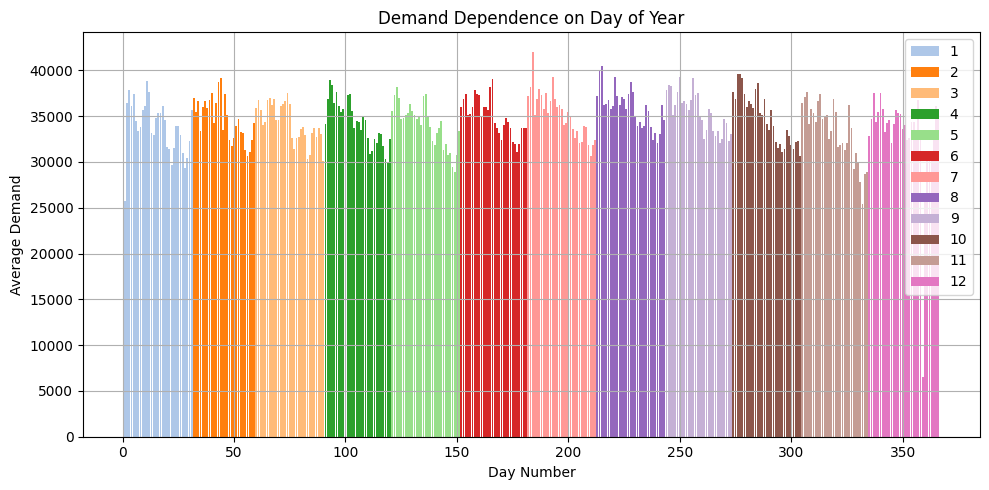

In [84]:
import datetime

fig, ax = plt.subplots(1, 1, figsize=(10, 5))

for row in sorted(count_per_day, key=lambda row: row.day_of_year):
    is_the_first_day_of_month = (
        datetime.date(year=2000, month=1, day=1) +
        datetime.timedelta(days=row.day_of_year - 1) ==
        datetime.date(year=2000, month=row.month, day=1)
    )
    ax.bar(
        row.day_of_year, row.Count, color=plt.get_cmap('tab20')(row.month),
        label=f'{row.month}' if is_the_first_day_of_month else None
    )

ax.legend()
ax.grid(True)

ax.set_xlabel('Day Number')
ax.set_ylabel('Average Demand')
ax.set_title('Demand Dependence on Day of Year')

fig.tight_layout()
plt.show()